In [2]:
!pip install -q librosa soundfile scikit-learn

In [3]:
import tensorflow as tf
import os

DATA_URL = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz" #google speech command dataset
DATA_DIR = "/content/speech_commands"

os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading dataset")
tf.keras.utils.get_file(
    "speech_commands.tar.gz",
    origin=DATA_URL,
    extract=True,
    cache_dir="/content",
    cache_subdir="speech_commands"
)

print("Done!")

2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
Done!


In [5]:
for root, dirs, files in os.walk("/content"):
    if "_background_noise_" in dirs:
        print("Dataset found at:", root)
        break

Dataset found at: /content/speech_commands/speech_commands_extracted


In [6]:
DATA_DIR = "/content/speech_commands/speech_commands_extracted"
words = sorted([
    folder for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

print("Number of classes:", len(words))
print("Classes:", words)

Number of classes: 36
Classes: ['_background_noise_', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [10]:
selected_words = [
    "yes", "no", "up", "down", "left",
    "right", "on", "off", "stop", "go"
]

print("Classes:", selected_words)
print("Number of classes:", len(selected_words))

Classes: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
Number of classes: 10


In [11]:
from collections import Counter
counts = {}

for word in selected_words:
    folder = os.path.join(DATA_DIR, word)
    files = [f for f in os.listdir(folder) if f.endswith(".wav")]
    counts[word] = len(files)

print(counts)

{'yes': 4044, 'no': 3941, 'up': 3723, 'down': 3917, 'left': 3801, 'right': 3778, 'on': 3845, 'off': 3745, 'stop': 3872, 'go': 3880}


In [12]:
import random
random.seed(42)

files = []
labels = []

for label, word in enumerate(selected_words):
    folder = os.path.join(DATA_DIR, word)
    wav_files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    random.shuffle(wav_files)
    wav_files = wav_files[:1000]

    for file in wav_files:
        files.append(os.path.join(folder, file))
        labels.append(label)

print("Total audio files:", len(files))
print("Total labels:", len(labels))

Total audio files: 10000
Total labels: 10000


In [13]:
from sklearn.model_selection import train_test_split

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)
print("Training:", len(train_files))
print("Validation:", len(val_files))
print("Testing:", len(test_files))

Training: 8000
Validation: 1000
Testing: 1000


In [14]:
import librosa
import numpy as np
audio, sample_rate = librosa.load(train_files[0], sr=16000)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print("Audio shape:", audio.shape)
print("Sample rate:", sample_rate)
print("MFCC shape:", mfcc.shape)

Audio shape: (16000,)
Sample rate: 16000
MFCC shape: (40, 32)


In [18]:
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Make every MFCC exactly 40 x 32
    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, 32 - mfcc.shape[1])),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :32]

    return mfcc

In [19]:
test_mfcc = extract_mfcc(train_files[0])

print("MFCC shape:", test_mfcc.shape)

MFCC shape: (40, 32)


In [20]:
from tqdm import tqdm

X_train = np.array([
    extract_mfcc(file)
    for file in tqdm(train_files)
])

X_val = np.array([
    extract_mfcc(file)
    for file in tqdm(val_files)
])

X_test = np.array([
    extract_mfcc(file)
    for file in tqdm(test_files)
])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

100%|██████████| 1000/1000 [00:05<00:00, 191.51it/s]

X_train shape: (8000, 40, 32)
X_val shape: (1000, 40, 32)
X_test shape: (1000, 40, 32)


In [21]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(train_labels, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: torch.Size([8000, 1, 40, 32])
y_train: torch.Size([8000])


In [22]:
import torch.nn as nn

class SpeechCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 10 * 8, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SpeechCNN(num_classes=10)

print(model)

SpeechCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [23]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Device:", device)
print("Batch size:", 64)
print("Learning rate:", 0.001)

Device: cuda
Batch size: 64
Learning rate: 0.001


In [24]:
epochs = 5

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    train_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {loss.item():.4f} "
        f"- Train Accuracy: {train_accuracy:.4f}"
    )

Epoch 1/5 - Loss: 2.2991 - Train Accuracy: 0.0976
Epoch 2/5 - Loss: 2.3146 - Train Accuracy: 0.1000
Epoch 3/5 - Loss: 2.2968 - Train Accuracy: 0.1000
Epoch 4/5 - Loss: 2.2993 - Train Accuracy: 0.1000
Epoch 5/5 - Loss: 2.3024 - Train Accuracy: 0.1000


In [25]:
print("Mean:", X_train.mean().item())
print("Std:", X_train.std().item())
print("Min:", X_train.min().item())
print("Max:", X_train.max().item())

print("Labels:", torch.unique(y_train))

Mean: -9.528919219970703
Std: 70.62489318847656
Min: -864.6740112304688
Max: 317.272216796875
Labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [26]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("New mean:", X_train.mean().item())
print("New std:", X_train.std().item())

New mean: 1.2516975012033527e-08
New std: 1.0


In [27]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

print("DataLoaders updated!")

DataLoaders updated!


In [28]:
model = SpeechCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model reset and ready for training!")

Model reset and ready for training!


In [29]:
epochs = 5

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        predicted = outputs.argmax(1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {loss.item():.4f} "
        f"- Accuracy: {accuracy:.4f}"
    )

Epoch 1/5 - Loss: 1.7632 - Accuracy: 0.2075
Epoch 2/5 - Loss: 1.4961 - Accuracy: 0.4215
Epoch 3/5 - Loss: 1.0467 - Accuracy: 0.5317
Epoch 4/5 - Loss: 1.1604 - Accuracy: 0.5985
Epoch 5/5 - Loss: 1.3654 - Accuracy: 0.6368


In [30]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predicted = outputs.argmax(1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

val_accuracy = correct / total

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.706


In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predicted = outputs.argmax(1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

test_accuracy = correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.71


In [32]:
from sklearn.metrics import classification_report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        predictions = outputs.argmax(1).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(y_batch.numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=selected_words
))

              precision    recall  f1-score   support

         yes       0.90      0.82      0.86       100
          no       0.66      0.61      0.63       100
          up       0.67      0.66      0.66       100
        down       0.67      0.62      0.65       100
        left       0.71      0.70      0.71       100
       right       0.76      0.90      0.83       100
          on       0.71      0.67      0.69       100
         off       0.57      0.81      0.67       100
        stop       0.80      0.81      0.81       100
          go       0.69      0.50      0.58       100

    accuracy                           0.71      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.72      0.71      0.71      1000



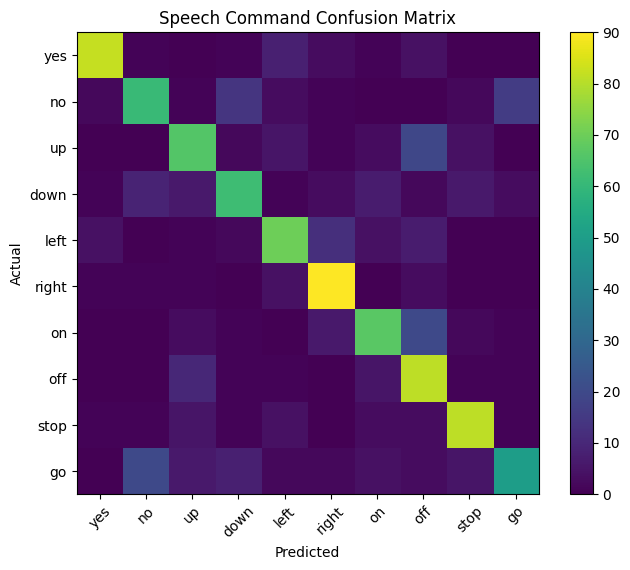

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.xticks(range(10), selected_words, rotation=45)
plt.yticks(range(10), selected_words)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Speech Command Confusion Matrix")

plt.colorbar()
plt.show()

In [34]:
model_tuned = SpeechCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_tuned = torch.optim.Adam(
    model_tuned.parameters(),
    lr=0.0005
)

epochs = 5

for epoch in range(epochs):
    model_tuned.train()
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_tuned.zero_grad()

        outputs = model_tuned(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer_tuned.step()

        predicted = outputs.argmax(1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {loss.item():.4f} "
        f"- Accuracy: {accuracy:.4f}"
    )

Epoch 1/5 - Loss: 2.0252 - Accuracy: 0.1893
Epoch 2/5 - Loss: 1.6068 - Accuracy: 0.3494
Epoch 3/5 - Loss: 1.1860 - Accuracy: 0.4542
Epoch 4/5 - Loss: 1.0608 - Accuracy: 0.5299
Epoch 5/5 - Loss: 1.3731 - Accuracy: 0.5739


In [35]:
model_tuned.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model_tuned(X_batch)
        predicted = outputs.argmax(1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

tuned_test_accuracy = correct / total

print("Tuned Test Accuracy:", tuned_test_accuracy)

Tuned Test Accuracy: 0.616


In [36]:
torch.save(model.state_dict(), "speech_command_cnn.pth")

print("Model saved!")

Model saved!
